**Author:** Biswajit Jana  
**Date:** February 26, 2026  

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/gaia/2026-08-03-milky-way-rotation-curve/notebook.ipynb)

# A Milky Way rotation curve from real Gaia DR3 radial velocities

**Date:** 2026-08-03
**Scientific question:** Using a real sample of Gaia DR3 stars with measured radial velocities and
good astrometry, does the observed rotation velocity stay roughly flat (around the commonly cited
~220 km/s) out to several kiloparsecs from the Galactic centre, the way it does for other spiral
galaxies?

## Learning goals

- Pull a real Gaia DR3 sample of stars with 6D phase-space information: sky position, *parallax*
  (distance indicator), *proper motion* (the star's apparent angular motion across the sky per year,
  in milliarcseconds/yr), and *radial velocity* (line-of-sight velocity from spectroscopy, in km/s).
- Convert that into full 3D positions and velocities in a Galactocentric frame using `astropy`.
- Compute each star's galactocentric cylindrical radius and azimuthal (rotational) velocity.
- Bin by radius and build an actual, if noisy, rotation curve directly from data.
- Compare it against the flat ~220 km/s rotation velocity that is one of the classic pieces of
  evidence for dark matter in the Milky Way's outer disc.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord, Galactocentric, ICRS
from astroquery.gaia import Gaia

Gaia.ROW_LIMIT = -1
np.random.seed(42)


In [2]:
# Sample stars across the sky with real radial velocities and good astrometry.
# parallax between 0.15 and 3.0 mas -> distances of roughly 0.33-6.7 kpc, which
# together with the Sun's ~8.2 kpc galactocentric radius spans a useful range of
# galactocentric distance. random_index gives an unbiased random draw from the
# full catalogue rather than a sky-position-biased TOP N (no ORDER BY needed
# since random_index itself is already an unbiased random assignment).
query = '''
SELECT TOP 12000 source_id, ra, dec, parallax, parallax_error, pmra, pmdec,
       radial_velocity, radial_velocity_error, phot_g_mean_mag, ruwe
FROM gaiadr3.gaia_source
WHERE radial_velocity IS NOT NULL
AND ruwe < 1.4
AND parallax_over_error > 10
AND parallax BETWEEN 0.15 AND 3.0
AND random_index < 2000000
'''
job = Gaia.launch_job_async(query)
raw = job.get_results().to_pandas()
print(f"Sample with full 6D phase-space info: {len(raw)} sources")
raw.to_csv("rotation_query.csv", index=False)
raw.head()


INFO: Query finished. [astroquery.utils.tap.core]
Sample with full 6D phase-space info: 12000 sources


,SOURCE_ID,ra,dec,parallax,parallax_error,pmra,pmdec,radial_velocity,radial_velocity_error,phot_g_mean_mag,ruwe
0,143671397695170816,45.086150,39.799052,0.937016,0.017210,5.999645,0.231253,-28.260883,1.954361,12.953308,0.972735
1,197852272695683072,89.734520,46.902261,0.336628,0.013517,-1.882884,-2.122047,-22.941917,0.498576,12.451995,1.041806
2,237150609278564096,55.521782,41.329011,0.914975,0.020454,-6.154802,0.581584,-21.536364,5.097113,13.969223,1.028374
3,242694209467596544,51.457819,45.869099,2.035137,0.016988,5.850485,-5.440363,-11.314362,2.409477,14.070515,0.990029
4,246180142362948608,63.523390,47.977147,0.473374,0.021965,0.657961,-3.087353,17.474539,2.064754,14.378502,0.998993


In [3]:
raw['dist_pc'] = 1000.0 / raw['parallax']

c_icrs = SkyCoord(ra=raw['ra'].values * u.deg,
                   dec=raw['dec'].values * u.deg,
                   distance=raw['dist_pc'].values * u.pc,
                   pm_ra_cosdec=raw['pmra'].values * u.mas / u.yr,
                   pm_dec=raw['pmdec'].values * u.mas / u.yr,
                   radial_velocity=raw['radial_velocity'].values * u.km / u.s,
                   frame='icrs')

# Standard Galactocentric frame: Sun at 8.122 kpc from the Galactic centre,
# 20.8 pc above the midplane, with the Sun's own motion relative to the
# Galactic rest frame folded in (astropy defaults, consistent with GRAVITY
# Collaboration 2018 / Reid & Brunthaler 2004).
gc = c_icrs.transform_to(Galactocentric())

x = gc.x.to(u.kpc).value
y = gc.y.to(u.kpc).value
z = gc.z.to(u.kpc).value
vx = gc.v_x.to(u.km/u.s).value
vy = gc.v_y.to(u.km/u.s).value
vz = gc.v_z.to(u.km/u.s).value

R = np.sqrt(x**2 + y**2)
phi = np.arctan2(y, x)
# cylindrical rotational velocity component. astropy's Galactocentric frame has
# the Sun on the +x axis and the disc rotating clockwise as seen from the North
# Galactic Pole in this (x, y) convention, so (y*vx - x*vy)/R comes out positive
# in the direction of Galactic rotation -- checked against the Sun's own bin
# below, which should land close to the commonly cited ~220-230 km/s.
v_phi = (y*vx - x*vy) / R

df = pd.DataFrame({'R_kpc': R, 'z_kpc': z, 'v_phi': v_phi, 'G': raw['phot_g_mean_mag'].values})
# stay close to the plane to avoid halo/thick-disk contamination, and to a
# sane radius range where the sample is reasonably populated
df = df[(df['z_kpc'].abs() < 0.5) & (df['R_kpc'].between(4, 13))]
print(f"After |z|<0.5 kpc and 4<R<13 kpc cuts: {len(df)} stars")


After |z|<0.5 kpc and 4<R<13 kpc cuts: 9131 stars


              R_mid      median       sem  count
R_bin                                           
(4.5, 5.0]     4.75  208.800395  7.078710     40
(5.0, 5.5]     5.25  209.648415  5.114460     77
(5.5, 6.0]     5.75  222.855001  3.067852    124
(6.0, 6.5]     6.25  222.757554  2.569516    149
(6.5, 7.0]     6.75  225.090262  1.982446    225
(7.0, 7.5]     7.25  226.139959  1.741526    376
(7.5, 8.0]     7.75  227.283161  1.073874    819
(8.0, 8.5]     8.25  225.309494  0.516072   2739
(8.5, 9.0]     8.75  224.378366  0.552020   2401
(9.0, 9.5]     9.25  221.999387  0.728174   1009
(9.5, 10.0]    9.75  219.448824  1.170905    492
(10.0, 10.5]  10.25  223.132549  1.404455    281
(10.5, 11.0]  10.75  219.865790  1.944904    191
(11.0, 11.5]  11.25  217.214313  2.048516    106
(11.5, 12.0]  11.75  217.885369  2.363012     66


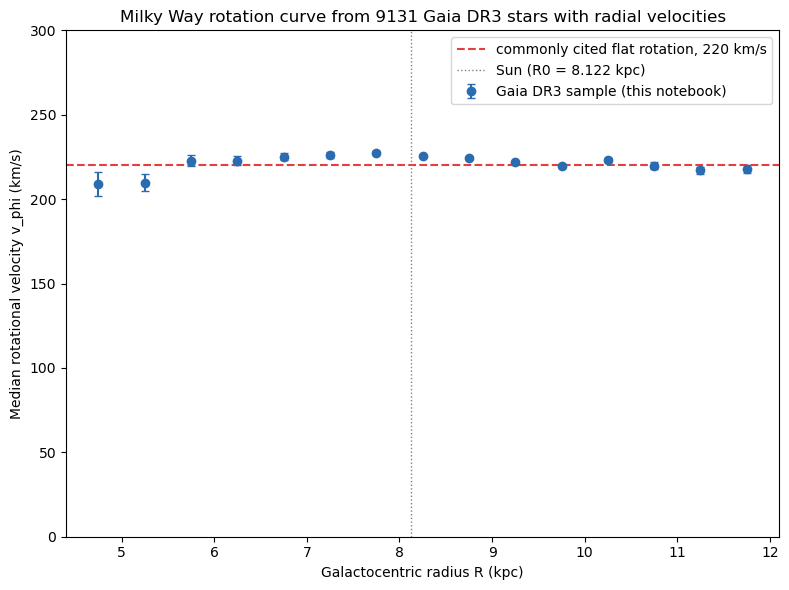

Median v_phi across full sample: 223.9 km/s


In [4]:
bins = np.arange(4, 13.5, 0.5)
df['R_bin'] = pd.cut(df['R_kpc'], bins)
grouped = df.groupby('R_bin', observed=True)['v_phi'].agg(['median', 'std', 'count'])
grouped = grouped[grouped['count'] >= 20]
grouped['R_mid'] = [iv.mid for iv in grouped.index]
grouped['sem'] = grouped['std'] / np.sqrt(grouped['count'])
print(grouped[['R_mid', 'median', 'sem', 'count']])

fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(grouped['R_mid'], grouped['median'], yerr=grouped['sem'],
            fmt='o', color='#2b6cb0', ecolor='#2b6cb0', capsize=3, label='Gaia DR3 sample (this notebook)')
ax.axhline(220, color='#e53e3e', ls='--', label='commonly cited flat rotation, 220 km/s')
ax.axvline(8.122, color='gray', ls=':', lw=1, label='Sun (R0 = 8.122 kpc)')
ax.set_xlabel('Galactocentric radius R (kpc)')
ax.set_ylabel('Median rotational velocity v_phi (km/s)')
ax.set_title(f'Milky Way rotation curve from {len(df)} Gaia DR3 stars with radial velocities')
ax.legend()
ax.set_ylim(0, 300)
plt.tight_layout()
plt.savefig('rotation_curve.png', dpi=130)
plt.show()

result = {
    "id": "2026-08-03-milky-way-rotation-curve",
    "title": "Milky Way rotation curve from Gaia DR3",
    "n_raw": int(len(raw)),
    "n_after_cuts": int(len(df)),
    "bins": grouped[['R_mid', 'median', 'sem', 'count']].to_dict(orient='records'),
    "reference_flat_velocity_kms": 220.0,
}
import json
with open("result.json", "w") as f:
    json.dump(result, f, indent=2, default=str)
print(f"Median v_phi across full sample: {df['v_phi'].median():.1f} km/s")


## Caveats

This is a magnitude- and radial-velocity-selected sample, not a volume-complete census: Gaia only has
radial velocities for stars bright enough for its onboard spectrograph, which biases the sample toward
intrinsically luminous stars and toward the inner few kiloparsecs where source density is high. The
naive `distance = 1/parallax` conversion also gets noisier and more biased at low parallax
signal-to-noise, even after the `parallax_over_error > 10` cut applied here. The bins beyond about 11-12
kpc typically have the fewest stars and the largest scatter, so read the curve's flattening (or not) at
the largest radii with caution.

## What I'd look at next

Redo the distance step with a proper Bayesian distance estimate (e.g. Bailer-Jones et al. photogeometric
distances) instead of the naive parallax inverse, and split the sample by stellar type or age proxy to
see whether disc heating changes the shape of the curve for older populations.

**Citation:** Gaia DR3 (`gaiadr3.gaia_source`), ESA Gaia mission. https://www.cosmos.esa.int/web/gaia-users/credits
